# Otimização de Markowitz — 100% Ativos de Bolsa

Refaz o processo original considerando **exclusivamente ativos de renda variável**.
O CDI continua sendo usado como taxa livre de risco no cálculo do Sharpe, mas **não integra a carteira**.

## 1. Importação das Bibliotecas

In [138]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize
import requests
import warnings
warnings.filterwarnings('ignore')

## 2. Funções Auxiliares

In [139]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    """Retorna (retorno anual, volatilidade anual) do portfólio."""
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol


def negative_sharpe(weights, df):
    """
    Sharpe anualizado com excesso de retorno em relação ao CDI diário real.
    df: DataFrame com retornos diários das ações + coluna 'cdi_daily'.
    """
    asset_returns  = df.iloc[:, :-1]   # todas as colunas exceto 'cdi_daily'
    cdi            = df['cdi_daily']
    port_returns   = asset_returns.dot(weights)
    excess_returns = port_returns - cdi
    sharpe = (excess_returns.mean() * 252) / (excess_returns.std() * np.sqrt(252))
    return -sharpe


def minimize_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]


def get_cdi_bcb(start_date, end_date):
    """CDI Over diário via API do Banco Central (série 12)."""
    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados"
        f"?formato=json&dataInicial={start_date}&dataFinal={end_date}"
    )
    df = pd.DataFrame(requests.get(url).json())
    df['data']      = pd.to_datetime(df['data'], dayfirst=True)
    df['valor']     = df['valor'].astype(float)
    df              = df.set_index('data').sort_index()
    df              = df.rename(columns={'valor': 'cdi_daily'})
    df['cdi_daily'] = df['cdi_daily'] / 100   # % -> decimal
    return df


print('Funcoes carregadas.')

Funcoes carregadas.


## 3. Definição dos Ativos e Coleta de Dados

In [140]:
# Mesmos ativos de bolsa do estudo original
tickers = [
"BEEF3.SA",
"ENGI11.SA",
"BPAC11.SA",
"SUZB3.SA", 
"TOTS3.SA",
"EMBJ3.SA"
]

period = '5y'

data   = yf.download(tickers, period=period, auto_adjust=True)
prices = data['Close'].dropna(how='all')

print(f'Periodo: {prices.index[0].date()} -> {prices.index[-1].date()}')
print(f'Observacoes: {len(prices)} dias uteis')

log_ret_prices = np.log(prices / prices.shift(1)).dropna()


[*********************100%***********************]  6 of 6 completed

Periodo: 2021-05-06 -> 2026-05-06
Observacoes: 1247 dias uteis


In [ ]:
prices.describe()

NameError: name 'summary' is not defined

In [148]:
log_ret_prices

Ticker,BEEF3.SA,BPAC11.SA,EMBJ3.SA,ENGI11.SA,SUZB3.SA,TOTS3.SA
Date,,,,,,
2025-10-28,0.008523,0.003978,0.031034,-0.026220,0.007331,0.025701
2025-10-29,-0.029578,0.033577,-0.015218,0.018082,-0.007479,-0.006667
2025-10-30,0.004354,-0.008878,-0.001364,-0.000772,-0.008350,0.012034
2025-10-31,0.037572,-0.006108,-0.010240,0.001352,0.004108,0.014635
2025-11-03,0.027855,-0.006555,0.003219,0.009647,-0.006954,-0.024115
...,...,...,...,...,...,...
2026-04-29,-0.032797,-0.026753,-0.030253,-0.032570,-0.013861,-0.012346
2026-04-30,0.000000,0.013147,0.009831,0.016160,-0.021766,0.021154
2026-05-04,0.047368,-0.020728,0.025441,-0.006437,-0.028741,0.021343


## 4. Retornos Diários e CDI

In [142]:
log_ret_prices = prices.pct_change().dropna()

start_str = log_ret_prices.index[0].strftime('%d/%m/%Y')
end_str   = log_ret_prices.index[-1].strftime('%d/%m/%Y')

cdi = get_cdi_bcb(start_str, end_str)
df  = log_ret_prices.join(cdi, how='inner')   # alinha datas

# Parametros anualizados (252 dias uteis)
mean_returns    = log_ret_prices.mean() * 252
cov_matrix      = log_ret_prices.cov()  * 252
mean_cdi_annual = (1 + df['cdi_daily']).prod()**(252/len(df)) - 1

print('Retorno medio anual por ativo:')
for t, r in mean_returns.items():
    print(f'  {t.replace(".SA",""):<10}: {r*100:.2f}%')
print(f'\nCDI medio anual (referencia Sharpe): {mean_cdi_annual*100:.2f}%')

Retorno medio anual por ativo:
  BEEF3     : -92.30%
  BPAC11    : 46.93%
  EMBJ3     : 2.88%
  ENGI11    : 28.38%
  SUZB3     : -19.99%
  TOTS3     : -41.77%

CDI medio anual (referencia Sharpe): 14.83%


## 5. Otimização — Portfólio de Máximo Sharpe (100% Bolsa)

Diferentemente do estudo original (75% bolsa / 25% CDI), aqui o portfólio é **inteiramente composto por ações**.
O CDI entra apenas como *benchmark* no denominador do Sharpe.

In [143]:
num_assets  = len(tickers)
peso_minimo = 0.05                                      # 5% minimo por ativo
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds      = tuple((peso_minimo, 1.0) for _ in range(num_assets))
init_guess  = [1.0 / num_assets] * num_assets

result = minimize(
    negative_sharpe,
    init_guess,
    args=(df,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
)

opt_weights          = result.x
opt_ret, opt_vol     = portfolio_performance(opt_weights, mean_returns, cov_matrix)
opt_sharpe           = (opt_ret - mean_cdi_annual) / opt_vol

print('Otimizacao concluida.')
print(f'Retorno esperado : {opt_ret*100:.2f}% a.a.')
print(f'Volatilidade     : {opt_vol*100:.2f}% a.a.')
print(f'Indice de Sharpe : {opt_sharpe:.4f}')

Otimizacao concluida.
Retorno esperado : 29.06% a.a.
Volatilidade     : 30.71% a.a.
Indice de Sharpe : 0.4633


## 6. Fronteira Eficiente

In [144]:
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 60)
efficient_vols = []

for target in target_returns:
    cons = (
        {'type': 'eq', 'fun': lambda x:       np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x, t=target: np.dot(x, mean_returns) - t},
    )
    res = minimize(
        minimize_volatility,
        init_guess,
        args=(mean_returns, cov_matrix),
        method='SLSQP',
        bounds=bounds,
        constraints=cons,
    )
    efficient_vols.append(res.fun)

# CAL a partir do ponto de tangencia (portfolio otimo de bolsa)
cal_slope     = (opt_ret - mean_cdi_annual) / opt_vol
cal_vols_plot = np.linspace(0, max(efficient_vols) * 1.3, 60)
cal_rets_plot = mean_cdi_annual + cal_slope * cal_vols_plot

print('Fronteira eficiente calculada.')

Fronteira eficiente calculada.


## 6.2 Simulação Monte Carlo — 10.000 Portfólios Aleatórios

In [145]:
N_SIM = 10_000
sim_rets   = np.zeros(N_SIM)
sim_vols   = np.zeros(N_SIM)
sim_sharpe = np.zeros(N_SIM)

rng = np.random.default_rng(seed=42)

for i in range(N_SIM):
    # Pesos aleatórios respeitando mínimo de 5%
    raw    = rng.random(num_assets)
    # Garante peso mínimo de peso_minimo por ativo
    w      = peso_minimo + (1 - peso_minimo * num_assets) * raw / raw.sum()
    r, v   = portfolio_performance(w, mean_returns, cov_matrix)
    sim_rets[i]   = r
    sim_vols[i]   = v
    sim_sharpe[i] = (r - mean_cdi_annual) / v

print(f'Simulação Monte Carlo concluída: {N_SIM:,} portfólios gerados.')

Simulação Monte Carlo concluída: 10,000 portfólios gerados.


## 7. Relatório de Alocação

In [146]:
print('\n' + '='*56)
print('  CARTEIRA OTIMIZADA - 100% ATIVOS DE BOLSA')
print('='*56)
print(f'  Retorno Esperado  : {opt_ret*100:.2f}% a.a.')
print(f'  Volatilidade      : {opt_vol*100:.2f}% a.a.')
print(f'  Indice de Sharpe  : {opt_sharpe:.4f}')
print(f'  CDI (referencia)  : {mean_cdi_annual*100:.2f}% a.a.')
print('='*56)
print(f'\n  {"Ativo":<12} {"Peso no Portfolio":>18}')
print('-'*32)
for ticker, w in sorted(zip(tickers, opt_weights), key=lambda x: -x[1]):
    nome = ticker.replace('.SA', '')
    print(f'  {nome:<12} {w*100:>17.2f}%')
print('='*56)


  CARTEIRA OTIMIZADA - 100% ATIVOS DE BOLSA
  Retorno Esperado  : 29.06% a.a.
  Volatilidade      : 30.71% a.a.
  Indice de Sharpe  : 0.4633
  CDI (referencia)  : 14.83% a.a.

  Ativo         Peso no Portfolio
--------------------------------
  ENGI11                   75.00%
  BEEF3                     5.00%
  TOTS3                     5.00%
  EMBJ3                     5.00%
  BPAC11                    5.00%
  SUZB3                     5.00%


## 8. Gráfico — Fronteira Eficiente e CAL (100% Bolsa)

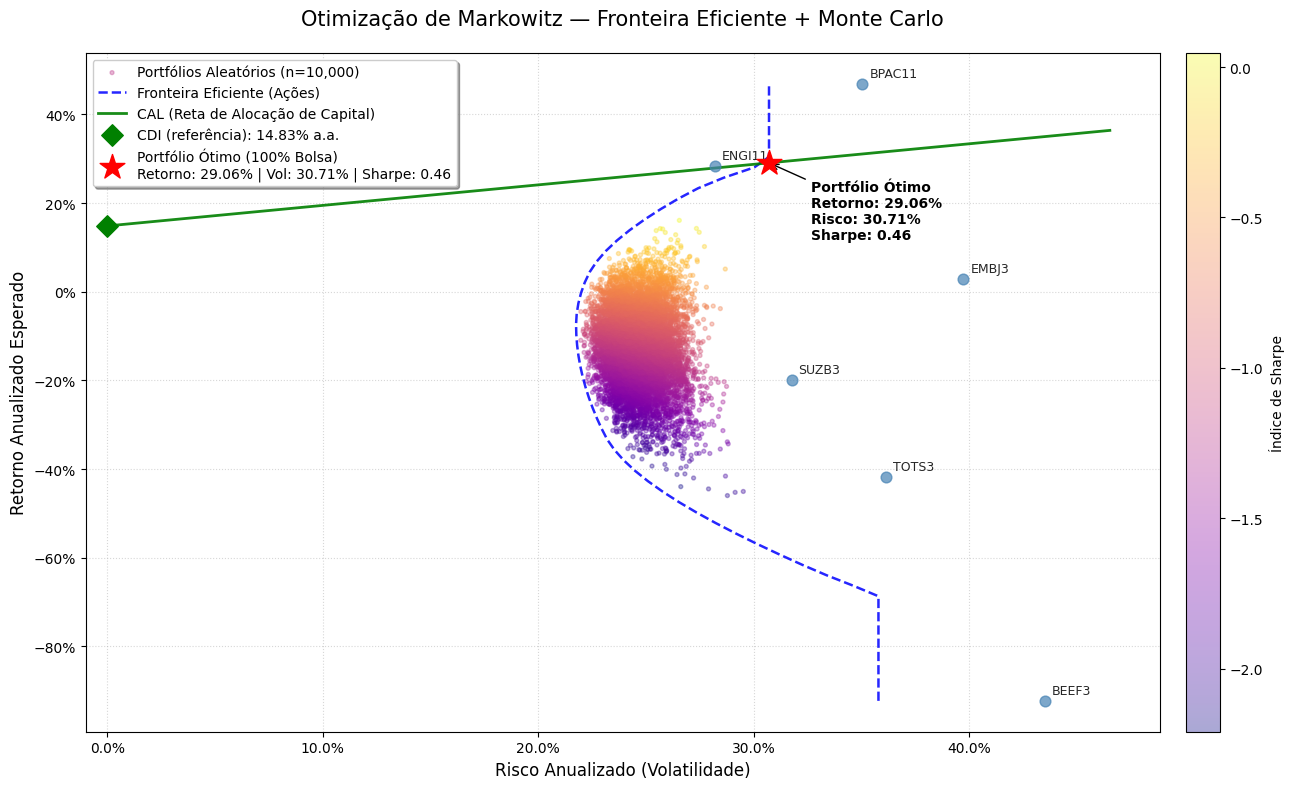

Gráfico salvo como markowitz_bolsa.png


In [147]:
fig, ax = plt.subplots(figsize=(14, 8))

# Portfólios aleatórios (Monte Carlo) coloridos pelo Sharpe
sc = ax.scatter(
    sim_vols, sim_rets,
    c=sim_sharpe, cmap='plasma',
    alpha=0.35, s=8, zorder=2,
    label=f'Portfólios Aleatórios (n={N_SIM:,})'
)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Índice de Sharpe', fontsize=10)

# Fronteira Eficiente
ax.plot(
    efficient_vols, target_returns,
    'b--', label='Fronteira Eficiente (Ações)',
    linewidth=1.8, alpha=0.85, zorder=3
)

# Capital Allocation Line
ax.plot(
    cal_vols_plot, cal_rets_plot,
    'g-', label='CAL (Reta de Alocação de Capital)',
    linewidth=2, alpha=0.9, zorder=3
)

# Ponto CDI (risk-free, risco zero)
ax.scatter(
    0, mean_cdi_annual,
    color='green', marker='D', s=120, zorder=6,
    label=f'CDI (referência): {mean_cdi_annual*100:.2f}% a.a.'
)

# Ponto de tangência: portfólio ótimo 100% bolsa
ax.scatter(
    opt_vol, opt_ret,
    color='red', marker='*', s=350, zorder=6,
    label=(
        f'Portfólio Ótimo (100% Bolsa)\n'
        f'Retorno: {opt_ret*100:.2f}% | '
        f'Vol: {opt_vol*100:.2f}% | '
        f'Sharpe: {opt_sharpe:.2f}'
    )
)
ax.annotate(
    f'Portfólio Ótimo\nRetorno: {opt_ret*100:.2f}%\nRisco: {opt_vol*100:.2f}%\nSharpe: {opt_sharpe:.2f}',
    xy=(opt_vol, opt_ret), xytext=(30, -55),
    textcoords='offset points', fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black')
)

# Ativos individuais
for ticker in tickers:
    vol = np.sqrt(cov_matrix.loc[ticker, ticker])
    ret = mean_returns[ticker]
    ax.scatter(vol, ret, marker='o', s=60, color='steelblue', alpha=0.7, zorder=5)
    ax.annotate(
        ticker.replace('.SA', ''), (vol, ret),
        textcoords='offset points', xytext=(5, 5), fontsize=9, alpha=0.85
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Otimização de Markowitz — Fronteira Eficiente + Monte Carlo', fontsize=15, pad=20)
ax.set_xlabel('Risco Anualizado (Volatilidade)', fontsize=12)
ax.set_ylabel('Retorno Anualizado Esperado', fontsize=12)
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(left=-0.01)

plt.tight_layout()
plt.savefig('markowitz_bolsa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo como markowitz_bolsa.png')

## 9. Nota sobre a diferença em relação ao estudo original

| Métrica | Original (75% Bolsa / 25% CDI) | Este notebook (100% Bolsa) |
|---|---|---|
| Composição | 75% ações + 25% CDI | 100% ações |
| Risco | `alocacao_bolsa × opt_vol` | `opt_vol` |
| Retorno | `0.75 × opt_ret + 0.25 × CDI` | `opt_ret` |
| CDI na carteira | ✅ | ❌ (apenas referência do Sharpe) |

> **Interpretação:** Ao alocar 100% em renda variável, o investidor se posiciona exatamente no ponto de tangência da CAL com a fronteira eficiente, maximizando o Sharpe. O tradeoff é maior retorno esperado com maior volatilidade — adequado para horizontes longos e perfil agressivo.